In [1]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [2]:
# Above cell I install external machine learning libraries
# required for the project. These libraries are not always
# pre-installed in Jupyter environments.

# XGBoost is used for advanced gradient boosting models
# which perform very well for fraud detection tasks.

In [3]:
#Importing Required Libraries
# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine learning algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Advanced boosting algorithm
import xgboost as xgb

# Model evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [4]:
# In this cell I import all the Python libraries needed
# for data manipulation, visualization, machine learning,
# and model evaluation.

# pandas → data manipulation and analysis
# numpy → numerical operations
# matplotlib & seaborn → data visualization
# sklearn → machine learning utilities

In [5]:
# Load dataset
df = pd.read_csv("creditcard.csv")

# Display first rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Here I load the Credit Card Fraud Detection dataset into a pandas DataFrame.

# The dataset contains transaction data where:
# Class = 0 → Normal transaction
# Class = 1 → Fraud transaction

In [7]:
df.shape # This shows how many rows and columns exist in the dataset.

(284807, 31)

In [8]:
# 284807 transactions and 31 features

In [9]:
# Before building machine learning models we must ensure
# that the dataset does not contain missing values.
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
#Result: dataset has no missing values

In [11]:
# This step checks how many fraud vs normal transactions exist.
df['Class'].value_counts() #EDA

Class
0    284315
1       492
Name: count, dtype: int64

In [12]:
#Fraud transactions are very rare
#Dataset is highly imbalanced

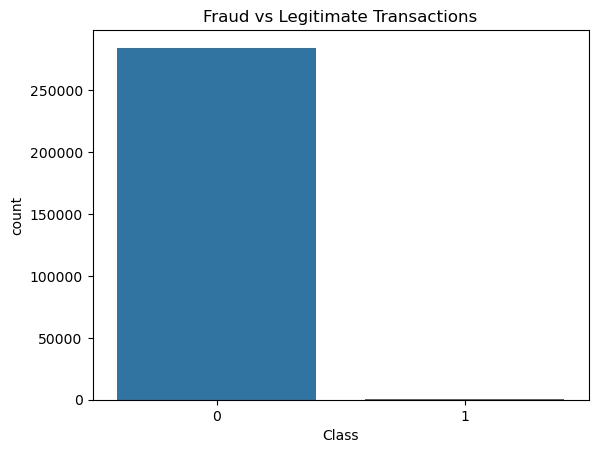

In [13]:
sns.countplot(x='Class', data=df)        #This visualization helps us clearly see how imbalanced the dataset is.
plt.title("Fraud vs Legitimate Transactions")
plt.show()

In [14]:
#Interpretation
#Class 0 = Normal
#Class 1 = Fraud

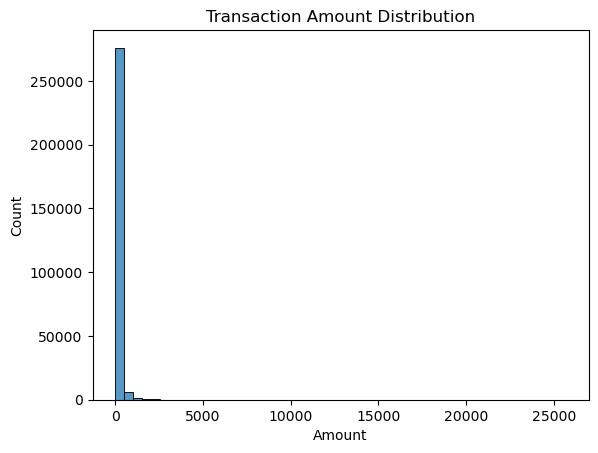

In [15]:
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()                                        
#This helps detect: Outliers and Suspicious high-value transactions

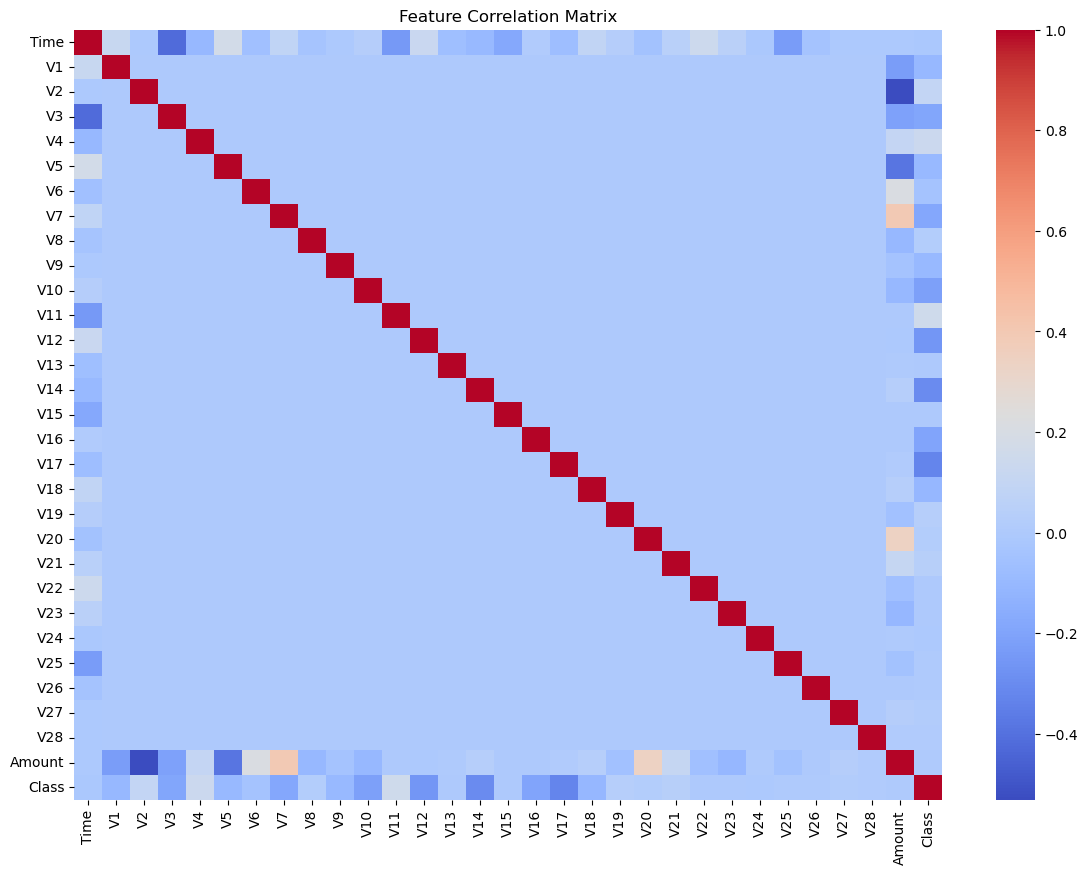

In [16]:
plt.figure(figsize=(14,10))                    # Correlation Analysis
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [17]:
# Feature Scaling
# Machine learning models perform better when numerical features are scaled.
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])      # We scale the 'Amount' feature using StandardScaler. 

#Standardization converts values into a distribution with:
#Mean = 0
#Standard deviation = 1

In [18]:
# Feature and Target Separation
X = df.drop('Class', axis=1)      # X → input features used by the model
y = df['Class']                   # y → target variable (fraud or not)

In [19]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,                    #80% training data
    random_state=42,                  #20% testing data
    stratify=y
)

In [20]:
pip install smote

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [21]:
# Handling Class Imbalance with SMOTE
# Since fraud cases are very rare, we apply SMOTE (Synthetic Minority Oversampling Technique).
# SMOTE creates synthetic fraud samples to balance the dataset.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [22]:
# Model 1 — Logistic Regression
lr = LogisticRegression(
    solver="liblinear",
    max_iter=5000
)

lr.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))
# Logistic Regression is a baseline classification algorithm.

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.10      0.90      0.18        98

    accuracy                           0.99     56962
   macro avg       0.55      0.94      0.59     56962
weighted avg       1.00      0.99      0.99     56962



In [23]:
# Model 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test)

# Random Forest is an ensemble model that combines multiple decision trees to improve prediction accuracy.

In [24]:
# Model 3:  XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    n_jobs=-1
)

xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb)) 

# XGBoost is an advanced gradient boosting algorithm
# widely used in fraud detection and financial modeling.

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.90      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.94      0.63     56962
weighted avg       1.00      0.99      0.99     56962



In [25]:
# Model 4 — Isolation Forest  (Anomaly Detection)
iso = IsolationForest(
    n_estimators=100,
    contamination=0.002,
    random_state=42
)

iso.fit(X_train)

y_pred_iso = iso.predict(X_test)

# These predictions help identify transactions that significantly deviate from normal behavior patterns.

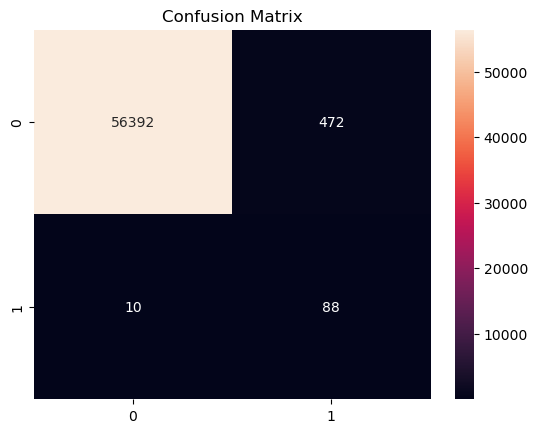

In [26]:
# Model Evaluation
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# Confusion Matrix helps evaluate classification performance.

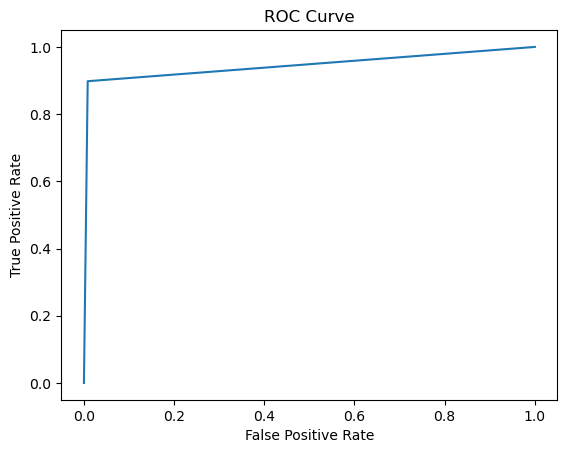

In [27]:
fpr, tpr, _ = roc_curve(y_test, y_pred_xgb)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# In fraud detection, ROC curves help measure how well the
# model separates fraudulent transactions from legitimate ones.

In [28]:
param_grid = {
    'max_depth':[4,6],
    'n_estimators':[100],
    'learning_rate':[0.05]
}

grid = GridSearchCV(
    xgb.XGBClassifier(tree_method="hist"),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_resampled, y_train_resampled)

print(grid.best_params_)

{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100}


In [55]:
# Best hyperparameters identified by GridSearchCV
# learning_rate = 0.05
# max_depth = 6
# n_estimators = 100

In [30]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


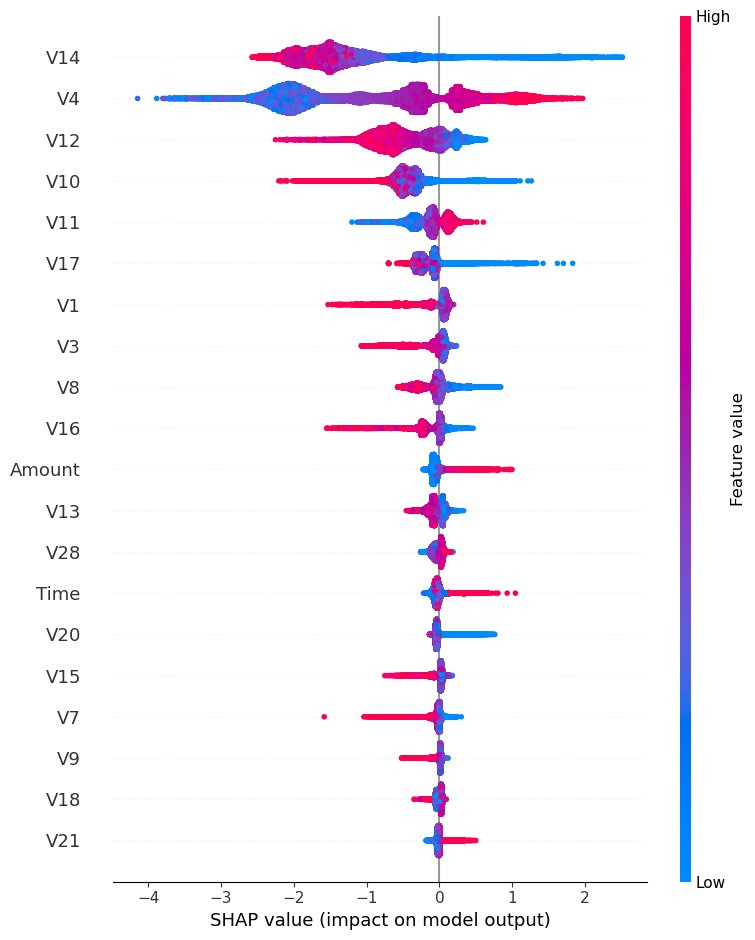

In [31]:
import shap
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)


shap.summary_plot(shap_values, X_test)

In [32]:
# SHAP (SHapley Additive exPlanations) is used to interpret
# machine learning models by explaining how each feature contributes to a prediction.

# In financial fraud detection, model transparency is
# extremely important because financial institutions must
# understand why a transaction was flagged as fraud.

# TreeExplainer is specifically optimized for tree based models such as XGBoost.

# The SHAP summary plot shows:
# - Feature importance ranking
# - Impact of feature values on predictions

# Each dot represents one transaction.
# Red → high feature value
# Blue → low feature value

# Features at the top of the plot (e.g., V14, V4, V12)
# have the strongest influence on fraud prediction.

In [33]:
#Deep Learning Autoencoder

In [34]:
#implementing an Autoencoder neural network using TensorFlow and Keras.

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Input layer
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder compresses features
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu")(encoded)

# Decoder reconstructs data
decoded = Dense(16, activation="relu")(encoded)
decoded = Dense(input_dim, activation="sigmoid")(decoded)

# Autoencoder model
autoencoder = Model(input_layer, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

In [35]:
# Training the Autoencoder Model
autoencoder.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=256,
    validation_data=(X_test, X_test)
)

Epoch 1/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 375270752.0000 - val_loss: 373014880.0000
Epoch 2/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 375270848.0000 - val_loss: 373014880.0000
Epoch 3/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 375271040.0000 - val_loss: 373014880.0000
Epoch 4/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 375270976.0000 - val_loss: 373014880.0000
Epoch 5/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 375271200.0000 - val_loss: 373014880.0000
Epoch 6/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 375271360.0000 - val_loss: 373014880.0000
Epoch 7/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 375271104.0000 - val_loss: 373014880.0000
Epoch 8/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 375271104.0000 - val_loss: 373014880.0000
Epoch 9/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 375270976.0000 - val_loss: 373014880.0000
Epoch 10/20
891/891 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 375271040.0000 - val_

In [36]:
# Detecting Fraud using Reconstruction Error
reconstructions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)
threshold = np.percentile(mse, 95)
fraud_predictions = mse > threshold

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 968us/step


In [37]:
# Graph Based Fraud Detection using Network Analysis

In [38]:
import networkx as nx

G = nx.Graph()

for index, row in df.iterrows():
    card = row["V1"]
    merchant = row["V2"]

    G.add_edge(card, merchant)

In [39]:
# Fraudulent activities often occur in networks where multiple
# accounts interact with the same merchants or entities.

# In this section model the transaction dataset as a graph.

# Nodes represent entities such as cards or merchants.
# Edges represent transactions between these entities.

# NetworkX is used to construct the graph and analyze transaction relationships.

# This graph structure can reveal suspicious patterns
# such as fraud rings or unusual transaction clusters.

In [40]:
#Real Time Fraud Detection Pipeline

In [41]:
def detect_fraud(transaction):        # This function simulates a real time fraud detection system.
    features = scaler.transform(transaction)
    probability = xgb_model.predict_proba(features)
    if probability[0][1] > 0.8:
        return "Fraud Alert"
    else:
        return "Legitimate"

In [42]:
# When a new transaction arrives:

# 1. The transaction features are scaled using the trained StandardScaler.

# 2. The XGBoost model predicts the probability of fraud.

# 3. If the predicted fraud probability is greater than 0.8, the system generates a "Fraud Alert".

# 4. Otherwise, the transaction is classified as legitimate.

# This demonstrates how machine learning models can be
# integrated into real-time financial monitoring systems.

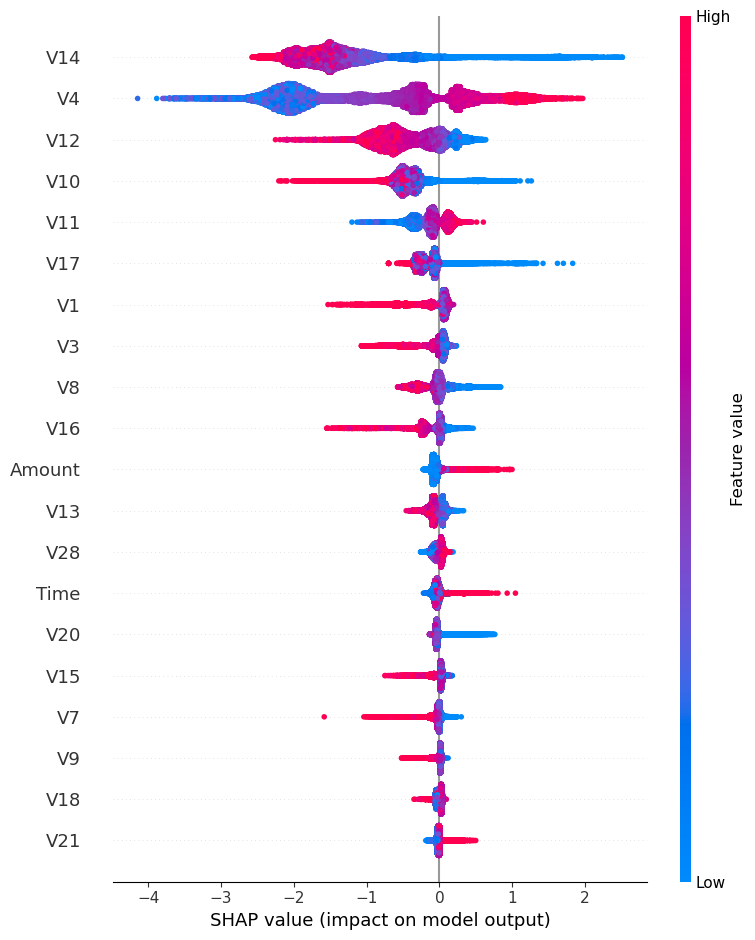

In [43]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [44]:
# Graph Based Fraud Detection Architecture

In [45]:
pip install torch-geometric

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [46]:
pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [47]:
import torch
print(torch.__version__)

2.10.0+cpu


In [48]:
# Graph Neural Network (GNN) Setup using PyTorch Geometric
import torch
import pandas as pd
import numpy as np
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [49]:
#Example structure:
#Node 1 → Card
#Node 2 → Merchant
#Edge → Transaction
# This example demonstrates how graph data is structured for Graph Neural Networks.

In [50]:
# Example nodes and edges

edge_index = torch.tensor([
    [0,1,2,3],
    [1,2,3,4]
], dtype=torch.long)

# Node features
x = torch.tensor([
    [1,0],
    [0,1],
    [1,1],
    [0,0],
    [1,0]
], dtype=torch.float)

# Labels
y = torch.tensor([0,0,1,0,1])

data = Data(x=x, edge_index=edge_index, y=y)

In [51]:
# Graph Convolutional Network (GCN) Model
class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(2, 16)
        self.conv2 = GCNConv(16, 2)
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

In [52]:
# Training the Graph Neural Network
model = GCN()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)
for epoch in range(200):
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out, data.y)
    loss.backward()
    optimizer.step()
    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 0.6392089128494263
Epoch: 1 Loss: 0.6293595433235168
Epoch: 2 Loss: 0.6205229759216309
Epoch: 3 Loss: 0.6125984191894531
Epoch: 4 Loss: 0.605483889579773
Epoch: 5 Loss: 0.5990455746650696
Epoch: 6 Loss: 0.5932866334915161
Epoch: 7 Loss: 0.5880330801010132
Epoch: 8 Loss: 0.5834358930587769
Epoch: 9 Loss: 0.5791102647781372
Epoch: 10 Loss: 0.575057327747345
Epoch: 11 Loss: 0.5712798833847046
Epoch: 12 Loss: 0.5677779912948608
Epoch: 13 Loss: 0.564376711845398
Epoch: 14 Loss: 0.5605638027191162
Epoch: 15 Loss: 0.5568825602531433
Epoch: 16 Loss: 0.5532990097999573
Epoch: 17 Loss: 0.5497718453407288
Epoch: 18 Loss: 0.5462705492973328
Epoch: 19 Loss: 0.54288250207901
Epoch: 20 Loss: 0.5403943061828613
Epoch: 21 Loss: 0.537768542766571
Epoch: 22 Loss: 0.5350255370140076
Epoch: 23 Loss: 0.5321853160858154
Epoch: 24 Loss: 0.5292553305625916
Epoch: 25 Loss: 0.5262284278869629
Epoch: 26 Loss: 0.5230889916419983
Epoch: 27 Loss: 0.5199601054191589
Epoch: 28 Loss: 0.5171072483062744
E

In [53]:
model.eval()                             #Fraud Prediction
pred = model(data).argmax(dim=1)
print(pred)

tensor([0, 0, 1, 0, 1])


In [54]:
# Output interpretation:
# 0 → Legitimate transaction
# 1 → Fraudulent transaction